Error loading dataset from URL: HTTP Error 404: Not Found
Please check the URL or your internet connection.
Using a small, hardcoded dataset as a fallback.
============================== K-MEANS CLUSTERING ==============================

Dataset shape:
(60, 5)

Number of rows: 60
Number of columns: 5

First 10 records:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              60 non-null     int64 
 1   Gender                  60 non-null     object
 2   Age                     60 non-null     int64 
 3   Annual Income (k$)      60 non-null     int64 
 4   Spending Score (1-100)  60 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 2.5+ KB

============================= MISSING VALUE CHECK ==============================
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total missing values: 0

============================= STATISTICAL SUMMARY ==============================


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,60.000000,60.000000,60.000000,60.000000
mean,30.500000,36.100000,43.816667,48.466667
std,17.464249,12.126033,23.143979,29.703316
min,1.000000,19.000000,15.000000,3.000000
25%,15.750000,27.000000,24.000000,20.000000
50%,30.500000,35.000000,40.000000,50.000000
75%,45.250000,42.750000,57.750000,74.250000
max,60.000000,67.000000,98.000000,99.000000


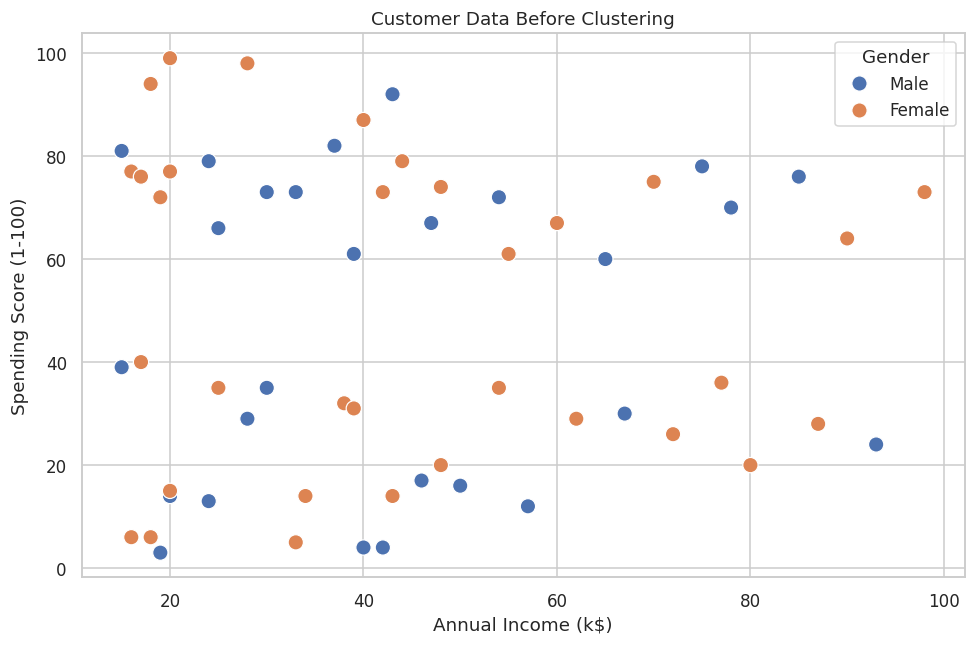


========================= FEATURES USED FOR CLUSTERING =========================
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40



Standardized data:


,Age,Annual Income (k$),Spending Score (1-100)
0,-1.422090,-1.255612,-0.321397
1,-1.255763,-1.255612,1.104519
2,-1.338927,-1.212039,-1.441760
3,-1.089437,-1.212039,0.968718
4,-0.424132,-1.168467,-0.287447


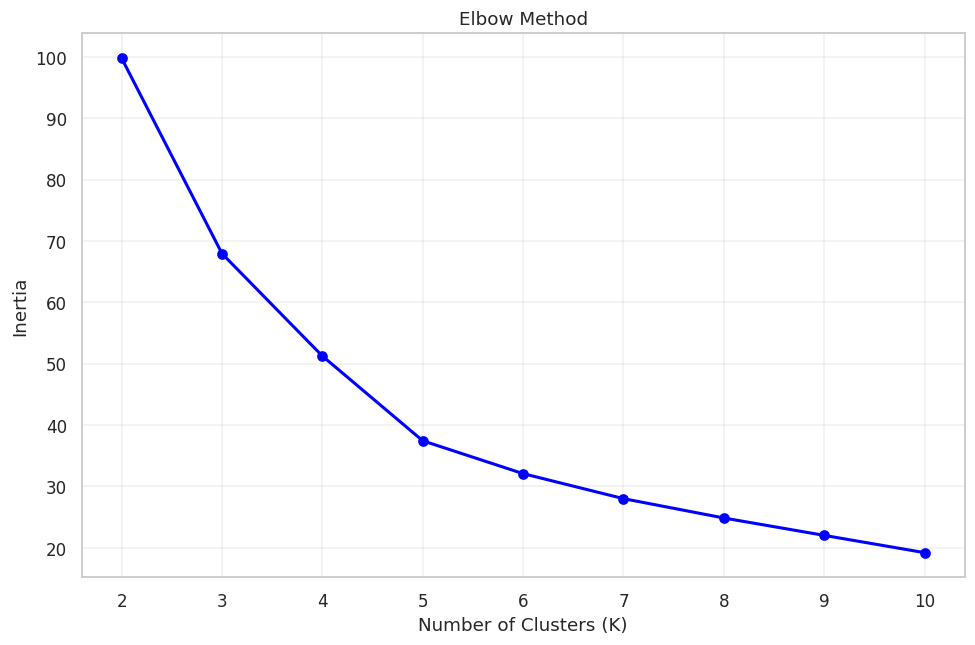

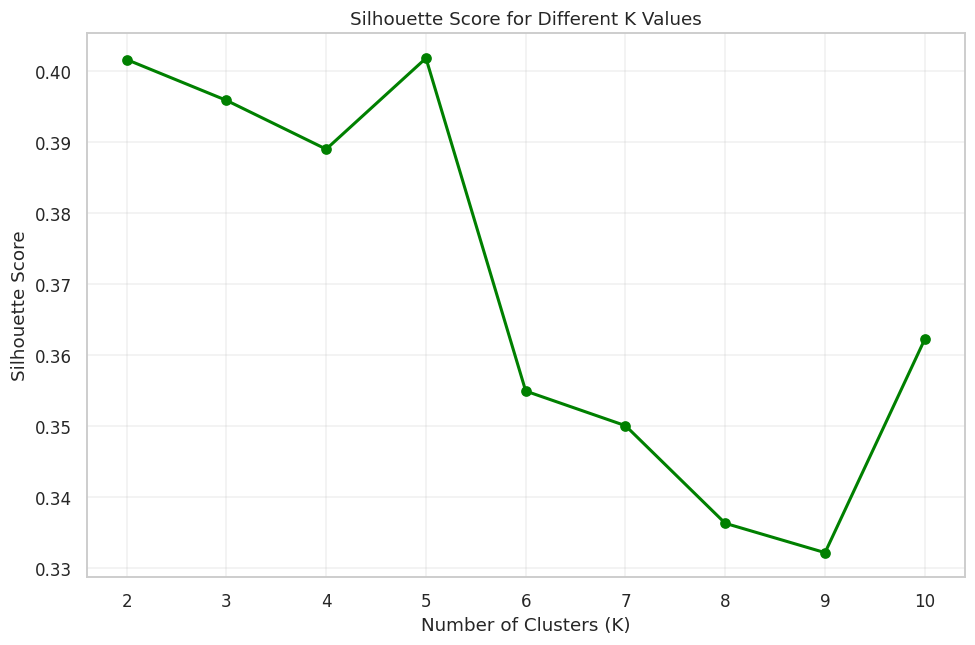


============================== K VALUE COMPARISON ==============================


,K,Inertia,Silhouette Score
0,2,99.78,0.4016
1,3,67.94,0.3958
2,4,51.26,0.3890
3,5,37.45,0.4018
4,6,32.09,0.3549
5,7,28.02,0.3501
6,8,24.87,0.3363
7,9,22.04,0.3322
8,10,19.22,0.3622



Selected number of clusters: 5

K-Means clustering completed successfully.

============================== CLUSTERED DATASET ===============================


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,5
1,2,Male,21,15,81,1
2,3,Female,20,16,6,5
3,4,Female,23,16,77,1
4,5,Female,31,17,40,5
5,6,Female,22,17,76,1
6,7,Female,35,18,6,5
7,8,Female,23,18,94,1
8,9,Male,64,19,3,2
9,10,Female,30,19,72,1



================================ CLUSTER COUNTS ================================
Cluster
1    19
2    11
3    11
4     9
5    10
Name: count, dtype: int64


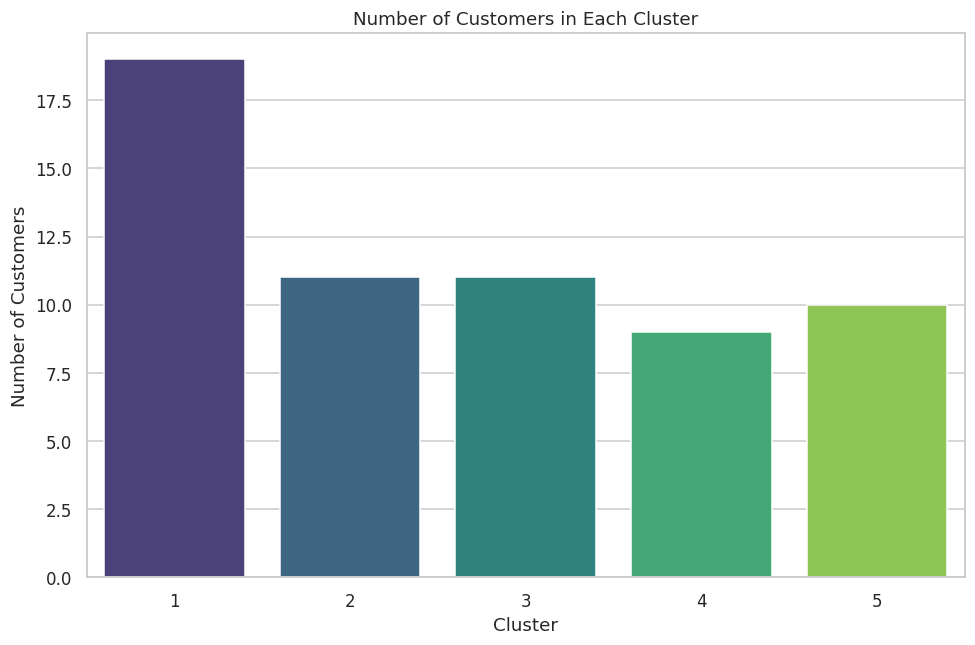


=========================== CLUSTER CHARACTERISTICS ============================


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
1,26.53,29.37,79.63
2,54.82,33.18,14.00
3,31.45,70.64,69.36
4,43.89,72.11,26.67
5,31.80,28.00,23.80



=============================== CLUSTER PROFILE ================================


,Number_of_Customers,Average_Age,Average_Income,Average_Spending_Score
Cluster,,,,
1,19,26.53,29.37,79.63
2,11,54.82,33.18,14.00
3,11,31.45,70.64,69.36
4,9,43.89,72.11,26.67
5,10,31.80,28.00,23.80


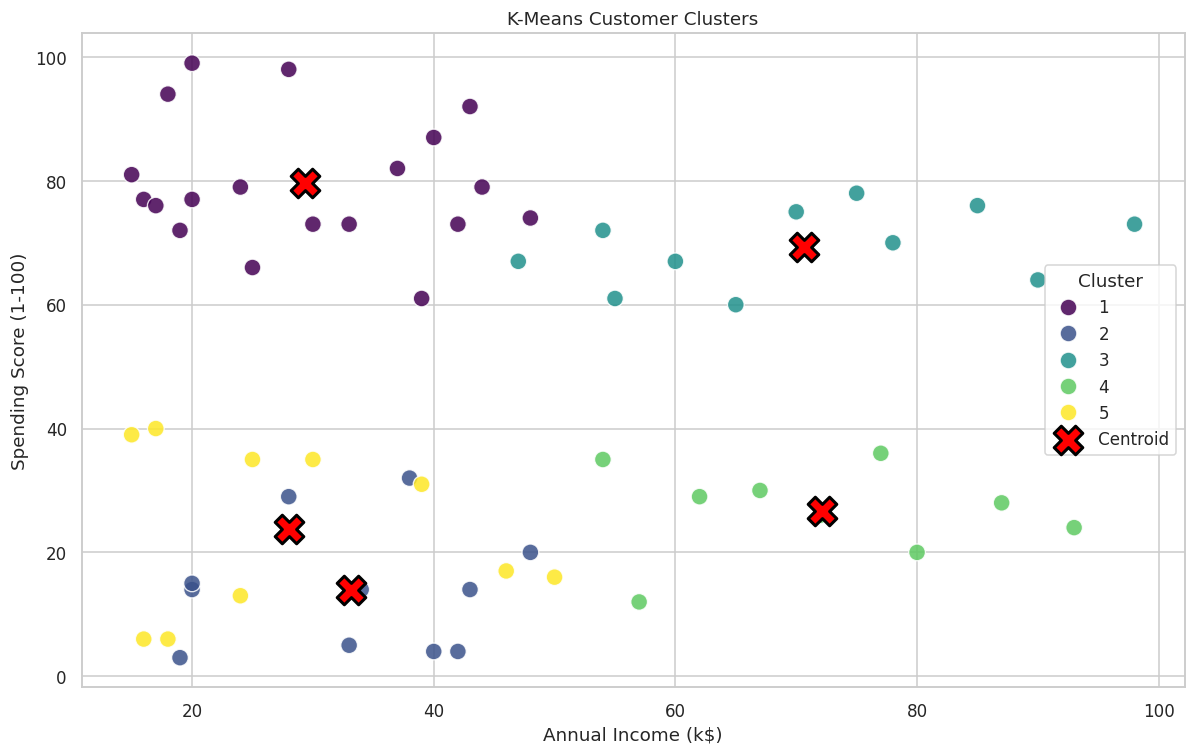

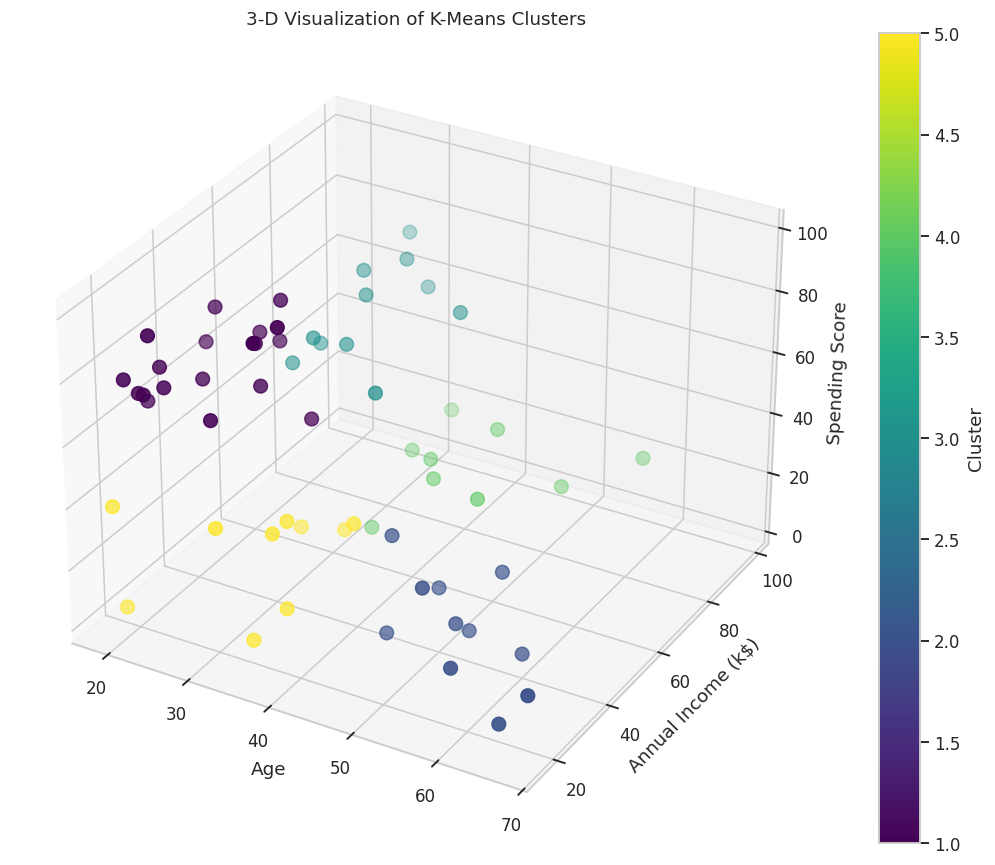

In [ ]:
# ============================================================================
# K-MEANS CLUSTERING
# BCI702 : Machine Learning
#
# AIM:
# Read an unsupervised dataset and group similar records using
# the K-Means clustering algorithm.
#
# Dataset:
# Mall Customers
#
# Features:
#   1. Age
#   2. Annual Income
#   3. Spending Score
#
# Techniques:
#   - Data preprocessing
#   - Feature scaling
#   - Elbow method
#   - Silhouette analysis
#   - K-Means clustering
#   - 2-D visualization
#   - 3-D visualization
#   - Cluster profiling
#   - New data prediction
# ============================================================================


# ============================================================================
# SECTION 1 : IMPORT LIBRARIES
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from mpl_toolkits.mplot3d import Axes3D

# Helper function to handle display() safely in both Jupyter and standard Python
try:
    from IPython.display import display
except ImportError:
    def display(df):
        print(df)


sns.set_theme(style="whitegrid")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11


# ============================================================================
# SECTION 2 : LOAD THE UNSUPERVISED DATASET FROM ONLINE SOURCE
# ============================================================================

dataset_url = "https://raw.githubusercontent.com/reddyprasade/Machine-Learning-Projects/main/K-Means%20Clustering/Mall_Customers.csv"

try:
    df = pd.read_csv(dataset_url)
    print(f"Dataset loaded successfully from {dataset_url}")

except Exception as e:
    print(f"Error loading dataset from URL: {e}")
    print("Please check the URL or your internet connection.")
    # Fallback to a hardcoded small dataset if online loading fails
    data = {
        "CustomerID": [
            1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
            11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
            21, 22, 23, 24, 25, 26, 27, 28, 29, 30,
            31, 32, 33, 34, 35, 36, 37, 38, 39, 40,
            41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
            51, 52, 53, 54, 55, 56, 57, 58, 59, 60
        ],
        "Gender": [
            "Male", "Male", "Female", "Female", "Female",
            "Female", "Female", "Female", "Male", "Female",
            "Male", "Female", "Female", "Female", "Male",
            "Male", "Female", "Male", "Male", "Female",
            "Male", "Male", "Female", "Male", "Female",
            "Male", "Female", "Male", "Female", "Female",
            "Male", "Female", "Male", "Male", "Female",
            "Female", "Male", "Male", "Female", "Female",
            "Male", "Male", "Female", "Female", "Male",
            "Female", "Female", "Male", "Male", "Female",
            "Female", "Male", "Female", "Male", "Female",
            "Male", "Female", "Female", "Male", "Female"
        ],
        "Age": [
            19, 21, 20, 23, 31, 22, 35, 23, 64, 30,
            67, 35, 58, 24, 37, 22, 35, 20, 52, 35,
            35, 25, 46, 31, 54, 29, 45, 35, 40, 23,
            60, 21, 53, 30, 49, 27, 31, 40, 55, 28,
            35, 30, 50, 27, 36, 32, 42, 27, 40, 31,
            36, 29, 45, 40, 52, 31, 36, 32, 58, 27
        ],
        "Annual Income (k$)": [
            15, 15, 16, 16, 17, 17, 18, 18, 19, 19,
            20, 20, 20, 20, 24, 24, 25, 25, 28, 28,
            30, 30, 33, 33, 34, 37, 38, 39, 39, 40,
            40, 42, 42, 43, 43, 44, 46, 47, 48, 48,
            50, 54, 54, 55, 57, 60, 62, 65, 67, 70,
            72, 75, 77, 78, 80, 85, 87, 90, 93, 98
        ],
        "Spending Score (1-100)": [
            39, 81, 6, 77, 40, 76, 6, 94, 3, 72,
            14, 99, 15, 77, 13, 79, 35, 66, 29, 98,
            35, 73, 5, 73, 14, 82, 32, 61, 31, 87,
            4, 73, 4, 92, 14, 79, 17, 67, 20, 74,
            16, 72, 35, 61, 12, 67, 29, 60, 30, 75,
            26, 78, 36, 70, 20, 76, 28, 64, 24, 73
        ]
    }
    df = pd.DataFrame(data)
    print("Using a small, hardcoded dataset as a fallback.")


# ============================================================================
# SECTION 3 : DISPLAY DATASET INFORMATION
# ============================================================================

print("=" * 80)
print(" K-MEANS CLUSTERING ".center(80, "="))
print("=" * 80)

print("\nDataset shape:")
print(df.shape)

print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nFirst 10 records:")
display(df.head(10))

print("\nDataset information:")
df.info()


# ============================================================================
# SECTION 4 : CHECK MISSING VALUES
# ============================================================================

print("\n" + "=" * 80)
print(" MISSING VALUE CHECK ".center(80, "="))
print("=" * 80)

print(df.isnull().sum())
total_missing = df.isnull().sum().sum()
print("\nTotal missing values:", total_missing)


# ============================================================================
# SECTION 5 : STATISTICAL SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print(" STATISTICAL SUMMARY ".center(80, "="))
print("=" * 80)

display(df.describe())


# ============================================================================
# SECTION 6 : VISUALIZE THE ORIGINAL DATA
# ============================================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Gender",
    s=100
)

plt.title("Customer Data Before Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.tight_layout()
plt.show()


# ============================================================================
# SECTION 7 : SELECT FEATURES FOR CLUSTERING
# ============================================================================

features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features].copy()

print("\n" + "=" * 80)
print(" FEATURES USED FOR CLUSTERING ".center(80, "="))
print("=" * 80)

print(features)
display(X.head())


# ============================================================================
# SECTION 8 : STANDARDIZE FEATURES
# ============================================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

print("\nStandardized data:")
display(X_scaled_df.head())


# ============================================================================
# SECTION 9 : ELBOW METHOD
# ============================================================================

inertias = []
K_values = range(2, 11)

for k in K_values:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(9, 6))
plt.plot(
    list(K_values),
    inertias,
    marker="o",
    color="blue",
    linewidth=2
)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(K_values))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================================
# SECTION 10 : SILHOUETTE ANALYSIS
# ============================================================================

silhouette_scores = []

for k in K_values:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)

plt.figure(figsize=(9, 6))
plt.plot(
    list(K_values),
    silhouette_scores,
    marker="o",
    color="green",
    linewidth=2
)
plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(K_values))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================================
# SECTION 11 : DISPLAY K VALUES AND SCORES
# ============================================================================

comparison_df = pd.DataFrame({
    "K": list(K_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

print("\n" + "=" * 80)
print(" K VALUE COMPARISON ".center(80, "="))
print("=" * 80)

display(
    comparison_df.style.format({
        "Inertia": "{:.2f}",
        "Silhouette Score": "{:.4f}"
    })
)


# ============================================================================
# SECTION 12 : SELECT OPTIMAL K
# ============================================================================

optimal_k = int(
    K_values[np.argmax(silhouette_scores)]
)

print("\nSelected number of clusters:", optimal_k)


# ============================================================================
# SECTION 13 : APPLY K-MEANS
# ============================================================================

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

# Shift cluster numbers to start from 1 instead of 0
df["Cluster"] = cluster_labels + 1

print("\nK-Means clustering completed successfully.")


# ============================================================================
# SECTION 14 : DISPLAY CLUSTERED DATA
# ============================================================================

print("\n" + "=" * 80)
print(" CLUSTERED DATASET ".center(80, "="))
print("=" * 80)

display(df.head(20))


# ============================================================================
# SECTION 15 : NUMBER OF RECORDS IN EACH CLUSTER
# ============================================================================

cluster_counts = df["Cluster"].value_counts().sort_index()

print("\n" + "=" * 80)
print(" CLUSTER COUNTS ".center(80, "="))
print("=" * 80)

print(cluster_counts)


# ============================================================================
# SECTION 16 : CLUSTER COUNT VISUALIZATION
# ============================================================================

plt.figure(figsize=(9, 6))

sns.barplot(
    x=cluster_counts.index.astype(str),
    y=cluster_counts.values,
    hue=cluster_counts.index.astype(str),
    palette="viridis",
    legend=False
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================================
# SECTION 17 : CLUSTER STATISTICS
# ============================================================================

cluster_summary = df.groupby("Cluster")[features].mean().round(2)

print("\n" + "=" * 80)
print(" CLUSTER CHARACTERISTICS ".center(80, "="))
print("=" * 80)

display(cluster_summary)


# ============================================================================
# SECTION 18 : CLUSTER SIZE TABLE
# ============================================================================

cluster_profile = df.groupby("Cluster").agg(
    Number_of_Customers=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending_Score=("Spending Score (1-100)", "mean")
).round(2)

print("\n" + "=" * 80)
print(" CLUSTER PROFILE ".center(80, "="))
print("=" * 80)

display(cluster_profile)


# ============================================================================
# SECTION 19 : 2-D CLUSTER VISUALIZATION
# ============================================================================

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="viridis",
    s=120,
    alpha=0.85
)

# Convert centroids back to original scale
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers_original[:, 1],
    centers_original[:, 2],
    marker="X",
    s=350,
    c="red",
    edgecolors="black",
    linewidths=2,
    label="Centroid"
)

plt.title("K-Means Customer Clusters")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


# ============================================================================
# SECTION 20 : 3-D CLUSTER VISUALIZATION
# ============================================================================

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["Age"],
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=80
)

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score")
ax.set_title("3-D Visualization of K-Means Clusters")

plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()


# ============================================================================
# SECTION 21 : PAIRPLOT
# ============================================================================

sns.pairplot(
    df,
    vars=features,
    hue="Cluster",
    palette="viridis",
    corner=True
)

plt.suptitle("Feature Relationships by Cluster", y=1.02)
plt.show()


# ============================================================================
# SECTION 22 : FINAL SILHOUETTE SCORE
# ============================================================================

final_silhouette = silhouette_score(X_scaled, cluster_labels)

print("\n" + "=" * 80)
print(" FINAL K-MEANS EVALUATION ".center(80, "="))
print("=" * 80)

print("\nNumber of clusters:", optimal_k)
print("Inertia:", round(kmeans.inertia_, 3))
print("Silhouette Score:", round(final_silhouette, 4))


# ============================================================================
# SECTION 23 : PRINT EACH CLUSTER PROFILE
# ============================================================================

print("\n" + "=" * 80)
print(" DETAILED CLUSTER PROFILE ".center(80, "="))
print("=" * 80)

for cluster in sorted(df["Cluster"].unique()):
    cluster_data = df[df["Cluster"] == cluster]

    print("\nCluster %d" % cluster)
    print("-" * 40)
    print("Number of customers:", len(cluster_data))
    print("Average age:", round(cluster_data["Age"].mean(), 2))
    print("Average annual income:", round(cluster_data["Annual Income (k$)"].mean(), 2))
    print("Average spending score:", round(cluster_data["Spending Score (1-100)"].mean(), 2))


# ============================================================================
# SECTION 24 : FIND THE CENTROIDS
# ============================================================================

centroid_df = pd.DataFrame(centers_original, columns=features)
centroid_df.index = centroid_df.index + 1
centroid_df.index.name = "Cluster"

print("\n" + "=" * 80)
print(" CLUSTER CENTROIDS ".center(80, "="))
print("=" * 80)

display(centroid_df.round(2))


# ============================================================================
# SECTION 25 : PREDICT CLUSTER FOR A NEW CUSTOMER
# ============================================================================

new_customer = pd.DataFrame({
    "Age": [30],
    "Annual Income (k$)": [65],
    "Spending Score (1-100)": [75]
})

new_customer_scaled = scaler.transform(new_customer)
predicted_cluster = kmeans.predict(new_customer_scaled)[0] + 1

print("\n" + "=" * 80)
print(" NEW CUSTOMER PREDICTION ".center(80, "="))
print("=" * 80)

print("\nNew customer:")
display(new_customer)

print("Assigned cluster:", predicted_cluster)


# ============================================================================
# SECTION 26 : DISPLAY CUSTOMERS FROM EACH CLUSTER
# ============================================================================

print("\n" + "=" * 80)
print(" CUSTOMERS GROUPED BY CLUSTER ".center(80, "="))
print("=" * 80)

for cluster in sorted(df["Cluster"].unique()):
    print("\nCluster %d:" % cluster)
    customers = df[df["Cluster"] == cluster][
        [
            "CustomerID",
            "Gender",
            "Age",
            "Annual Income (k$)",
            "Spending Score (1-100)"
        ]
    ]
    display(customers)


# ============================================================================
# SECTION 27 : SAVE CLUSTERED DATASET
# ============================================================================

output_file = "mall_customers_kmeans_clustered.csv"
df.to_csv(output_file, index=False)

print("\n" + "=" * 80)
print(" FILE EXPORT ".center(80, "="))
print("=" * 80)

print("\nClustered dataset saved as:", output_file)


# ============================================================================
# SECTION 28 : FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print(" FINAL SUMMARY ".center(80, "="))
print("=" * 80)

summary_text = f"""
K-MEANS CLUSTERING RESULTS
--------------------------

Dataset:
    Mall Customers

Clustering algorithm:
    K-Means

Number of clusters:
    {optimal_k}

Number of records:
    {len(df)}

Number of features used:
    {len(features)}

Features:
    Age
    Annual Income
    Spending Score

Final Inertia:
    {kmeans.inertia_:.3f}

Final Silhouette Score:
    {final_silhouette:.4f}

The K-Means algorithm grouped customers according to similarity
in their age, annual income and spending score.

The Elbow Method was used to examine the appropriate number
of clusters, while the Silhouette Score was used to measure
cluster separation.

The final dataset containing the cluster assignments was saved as:
    {output_file}
"""

print(summary_text)

print("=" * 80)
print(" END OF K-MEANS CLUSTERING EXPERIMENT ".center(80))
print("=" * 80)